# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The India Retail Sales Dataset](https://www.kaggle.com/datasets/abirambharathisa/india-retail-sales-dataset-2023-2025)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('sales_data.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,order_id,order_date,customer_id,gender,age,region,city,category,product,unit_price,quantity,discount,sales,profit,channel,payment_method,rating
0,ORD100001,2023-01-01,C00543,Male,43,North,Jaipur,Beauty,Sunscreen,557,4,0.00,2228.0,164.59,Store,UPI,5.0
1,ORD100002,2023-01-01,C01001,Female,40,South,Bengaluru,Home & Kitchen,Table Lamp,851,2,0.05,1616.9,160.72,Online,Cash on Delivery,4.0
2,ORD100003,2023-01-01,C00224,Female,34,East,Bhubaneswar,Books & Stationery,Exam Guide,544,1,0.10,489.6,75.61,Mobile App,UPI,4.0
3,ORD100004,2023-01-01,C01603,Male,27,East,Bhubaneswar,Home & Kitchen,Bedsheet Set,916,5,0.00,4580.0,439.43,Mobile App,UPI,4.0
4,ORD100005,2023-01-01,C00248,Male,21,West,Mumbai,Beauty,Sunscreen,574,1,0.05,545.3,116.65,Store,UPI,NaN


## last Five row

In [4]:
df.tail()

,order_id,order_date,customer_id,gender,age,region,city,category,product,unit_price,quantity,discount,sales,profit,channel,payment_method,rating
19995,ORD119996,2025-12-31,C00778,Male,65,West,Mumbai,Home & Kitchen,Table Lamp,868,2,0.10,1562.4,222.09,Store,UPI,4.0
19996,ORD119997,2025-12-31,C01467,Male,42,East,Guwahati,Clothing,Jacket,3160,5,0.00,15800.0,2844.95,Store,Credit Card,5.0
19997,ORD119998,2025-12-31,C02647,Female,59,West,Ahmedabad,Beauty,Shampoo,370,1,0.00,370.0,103.93,Store,Debit Card,5.0
19998,ORD119999,2025-12-31,C02991,Male,36,West,Pune,Books & Stationery,Novel,376,3,0.05,1071.6,248.00,Store,Debit Card,5.0
19999,ORD120000,2025-12-31,C01879,Female,61,North,Chandigarh,Electronics,Laptop,55946,2,0.00,111892.0,19328.07,Mobile App,Debit Card,3.0


## Shape of our dataset

In [5]:
df.shape

(20000, 17)

## List out all columns

In [6]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'gender', 'age', 'region',
       'city', 'category', 'product', 'unit_price', 'quantity', 'discount',
       'sales', 'profit', 'channel', 'payment_method', 'rating'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

order_id           object
order_date         object
customer_id        object
gender             object
age                 int64
region             object
city               object
category           object
product            object
unit_price          int64
quantity            int64
discount          float64
sales             float64
profit            float64
channel            object
payment_method     object
rating            float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        20000 non-null  object 
 1   order_date      20000 non-null  object 
 2   customer_id     20000 non-null  object 
 3   gender          20000 non-null  object 
 4   age             20000 non-null  int64  
 5   region          20000 non-null  object 
 6   city            20000 non-null  object 
 7   category        20000 non-null  object 
 8   product         20000 non-null  object 
 9   unit_price      20000 non-null  int64  
 10  quantity        20000 non-null  int64  
 11  discount        20000 non-null  float64
 12  sales           20000 non-null  float64
 13  profit          20000 non-null  float64
 14  channel         20000 non-null  object 
 15  payment_method  20000 non-null  object 
 16  rating          19800 non-null  float64
dtypes: float64(4), int64(3), object

## Check Null Value

In [9]:
df.isnull().sum()

order_id            0
order_date          0
customer_id         0
gender              0
age                 0
region              0
city                0
category            0
product             0
unit_price          0
quantity            0
discount            0
sales               0
profit              0
channel             0
payment_method      0
rating            200
dtype: int64

## Handle Rating Feacher

In [10]:
df = df.fillna(df.mean(numeric_only=True))

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,age,unit_price,quantity,discount,sales,profit,rating
count,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000
mean,41.550600,5318.760050,2.24070,0.061780,11103.890837,1716.807179,3.870556
std,13.904169,12745.262927,1.40544,0.079938,32356.829928,5677.073726,1.115627
min,18.000000,134.000000,1.00000,0.000000,100.100000,-14749.630000,1.000000
25%,30.000000,515.000000,1.00000,0.000000,902.000000,101.840000,3.000000
50%,41.000000,1281.500000,2.00000,0.050000,2128.000000,288.420000,4.000000
75%,54.000000,2735.000000,3.00000,0.100000,5456.850000,835.327500,5.000000
max,65.000000,60496.000000,5.00000,0.300000,301935.000000,88059.090000,5.000000


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

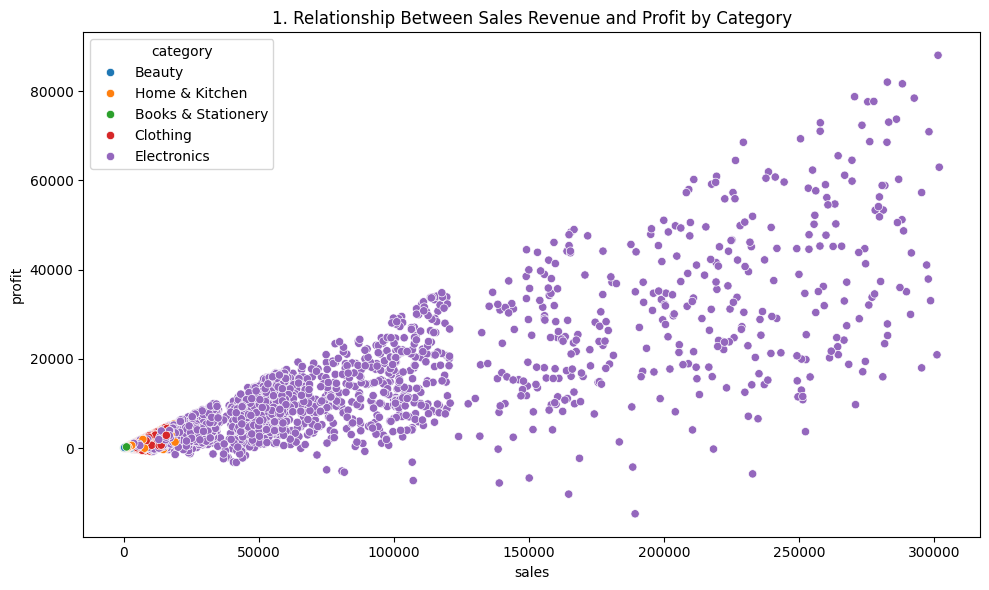

In [14]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='sales', y='profit', hue='category')
plt.title(f'{plot_no}. Relationship Between Sales Revenue and Profit by Category')
show_fig()
plot_no += 1

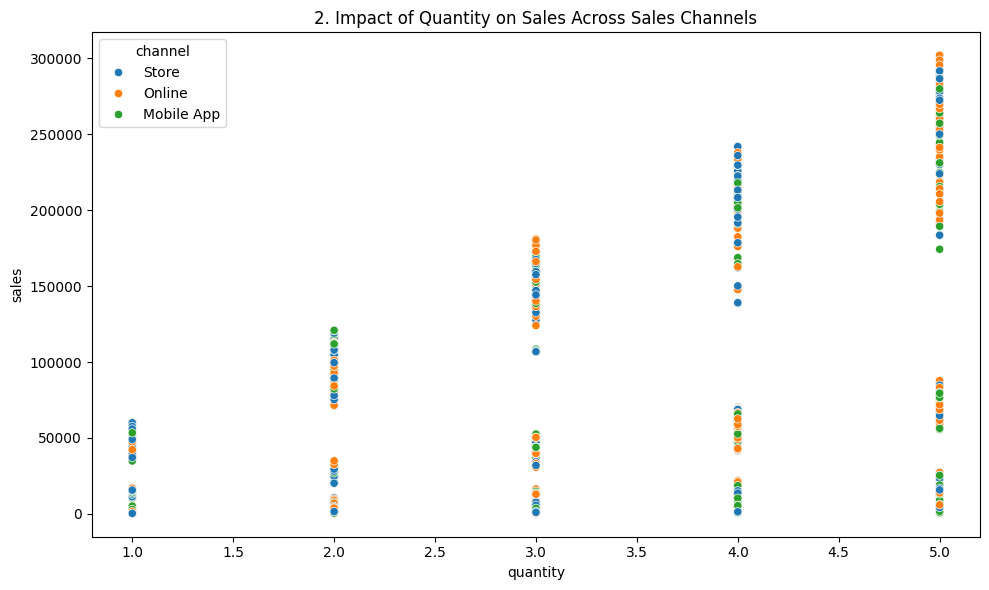

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='quantity', y='sales', hue='channel')
plt.title(f'{plot_no}. Impact of Quantity on Sales Across Sales Channels')
show_fig()
plot_no += 1

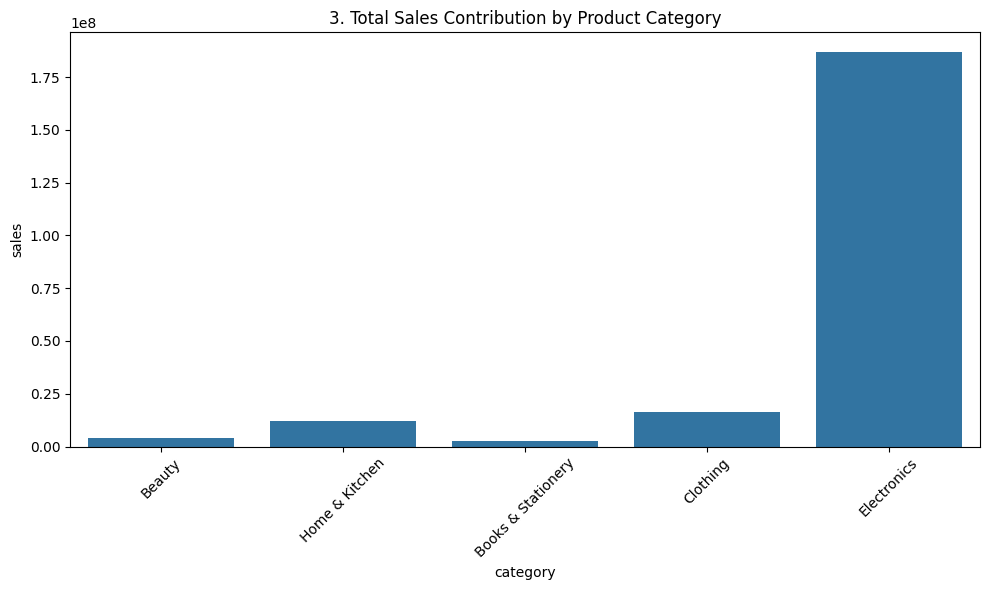

In [16]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='category', y='sales', estimator='sum', errorbar=None)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Total Sales Contribution by Product Category')
show_fig()
plot_no += 1

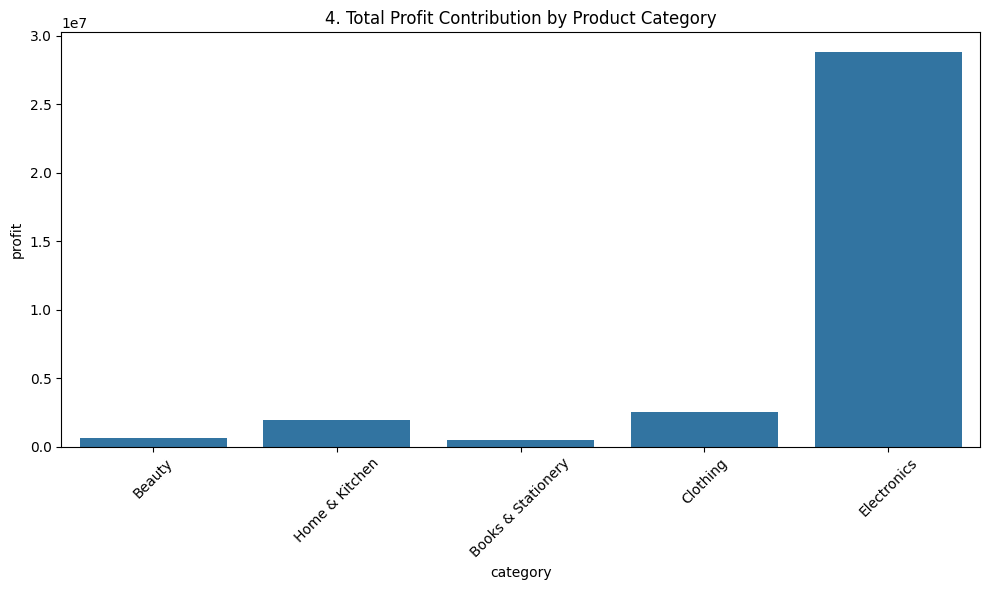

In [17]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='category', y='profit', estimator='sum', errorbar=None)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Total Profit Contribution by Product Category')
show_fig()
plot_no += 1

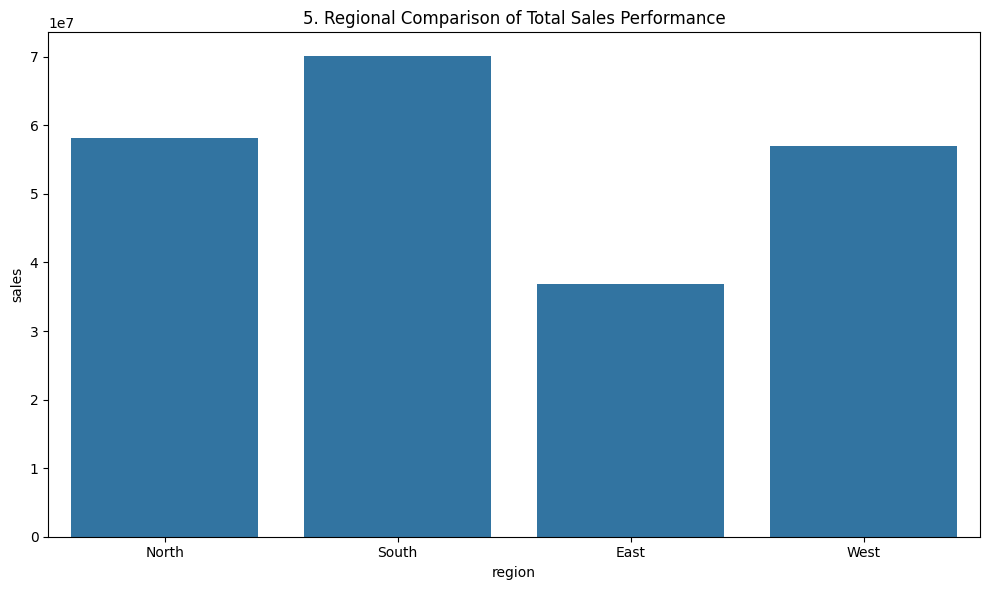

In [18]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='region', y='sales', estimator='sum', errorbar=None)
plt.title(f'{plot_no}. Regional Comparison of Total Sales Performance')
show_fig()
plot_no += 1

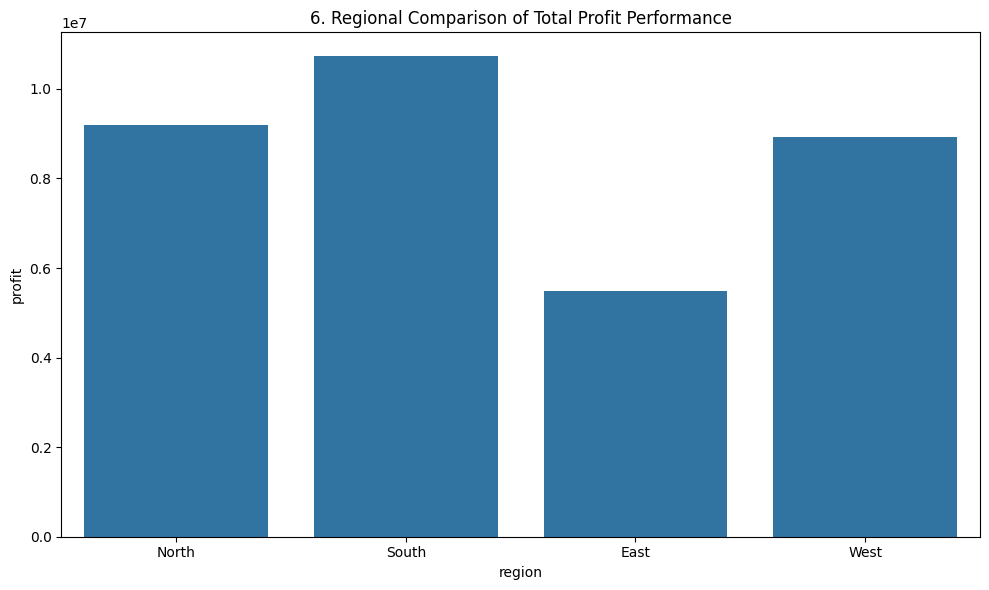

In [19]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='region', y='profit', estimator='sum', errorbar=None)
plt.title(f'{plot_no}. Regional Comparison of Total Profit Performance')
show_fig()
plot_no += 1

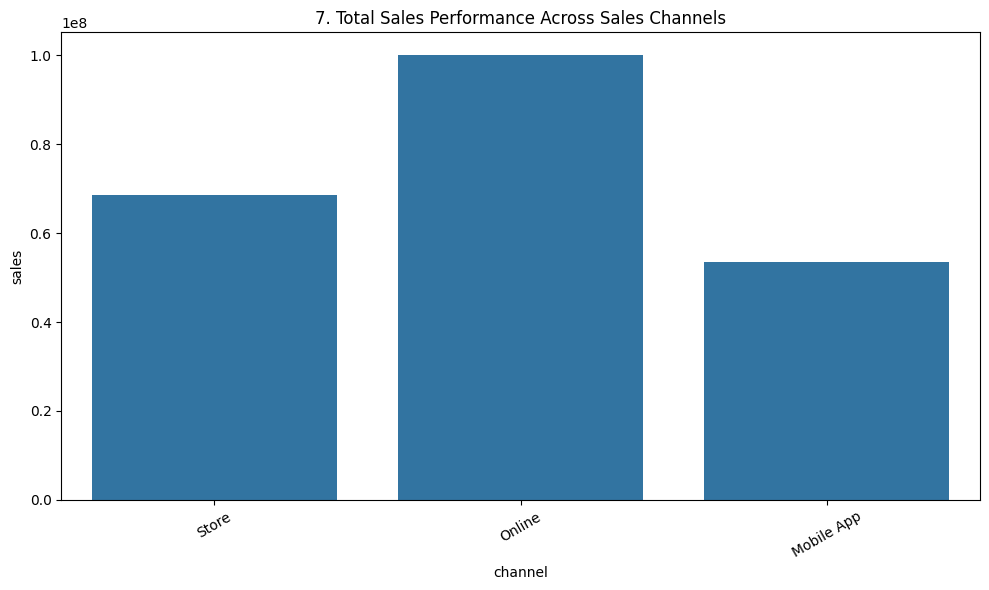

In [20]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='channel', y='sales', estimator='sum', errorbar=None)
plt.xticks(rotation=30)
plt.title(f'{plot_no}. Total Sales Performance Across Sales Channels')
show_fig()
plot_no += 1

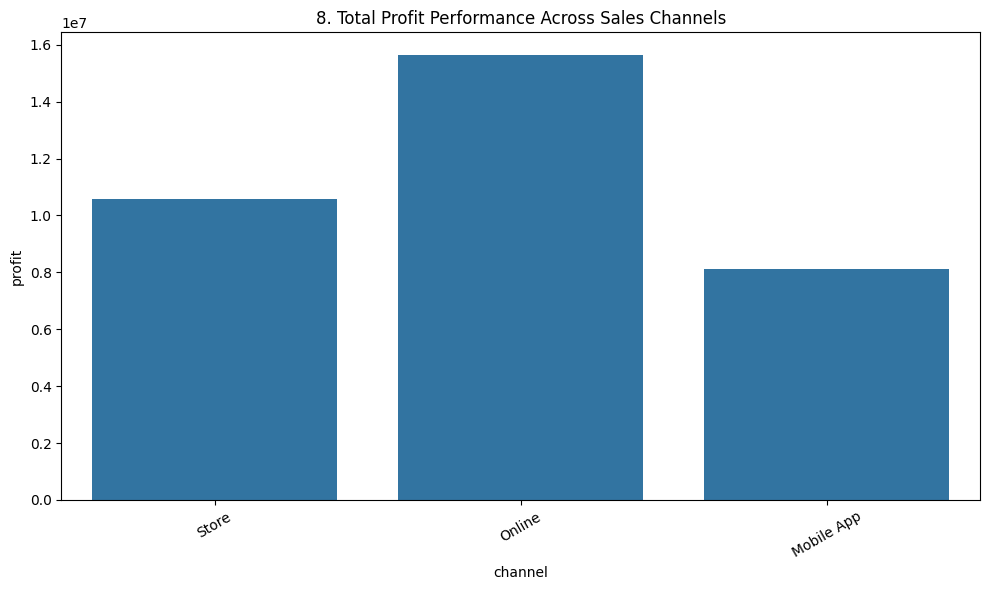

In [21]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='channel', y='profit', estimator='sum', errorbar=None)
plt.xticks(rotation=30)
plt.title(f'{plot_no}. Total Profit Performance Across Sales Channels')
show_fig()
plot_no += 1

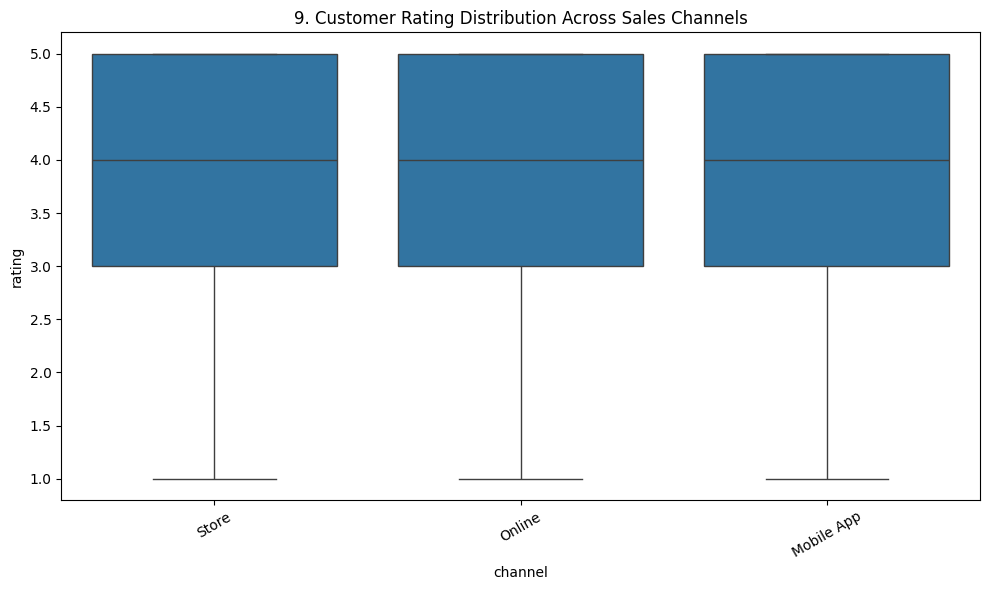

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='channel', y='rating')
plt.xticks(rotation=30)
plt.title(f'{plot_no}. Customer Rating Distribution Across Sales Channels')
show_fig()
plot_no += 1

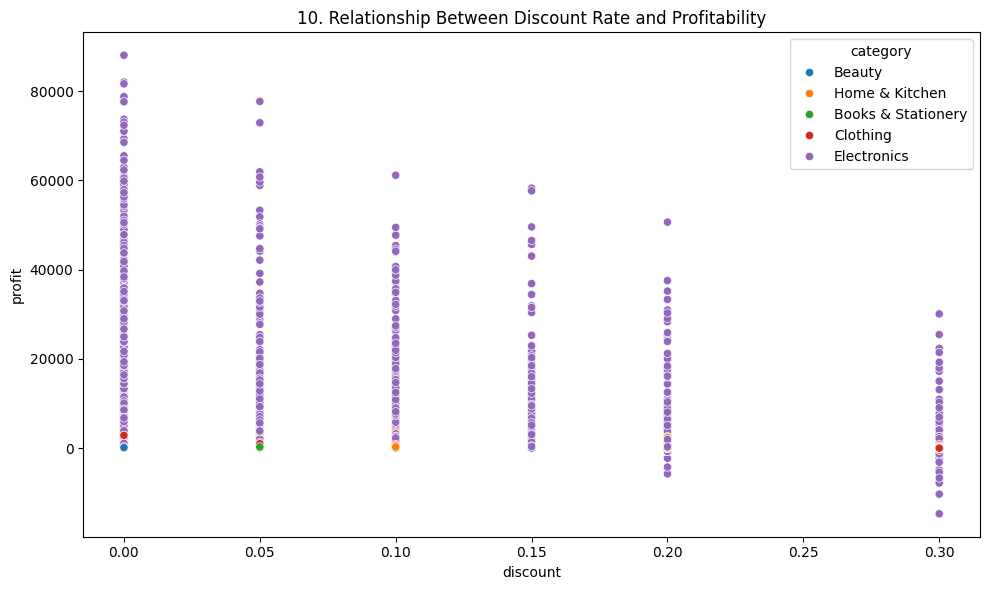

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='discount', y='profit', hue='category')
plt.title(f'{plot_no}. Relationship Between Discount Rate and Profitability')
show_fig()
plot_no += 1

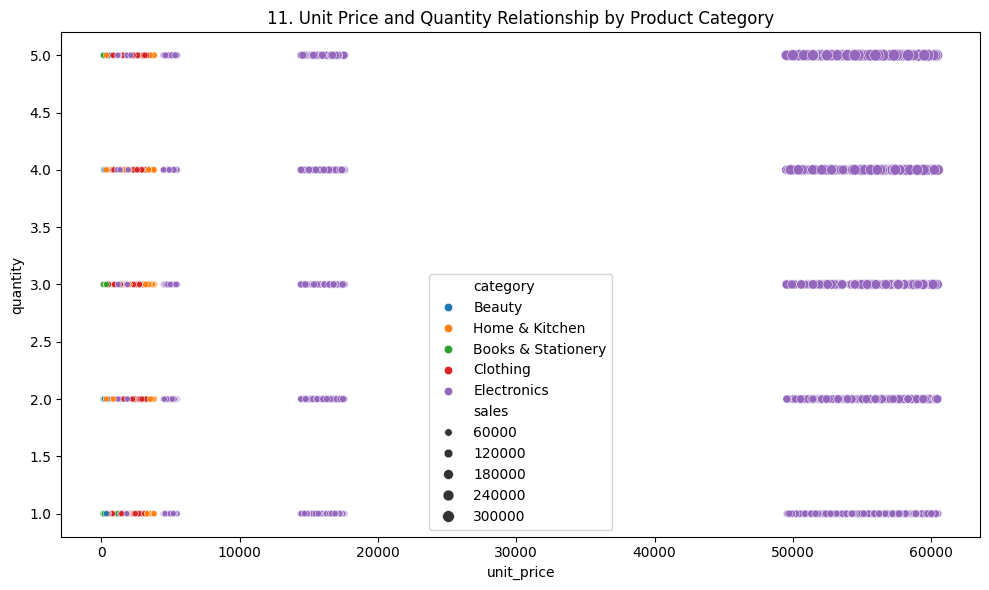

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='unit_price', y='quantity', size='sales', hue='category')
plt.title(f'{plot_no}. Unit Price and Quantity Relationship by Product Category')
show_fig()
plot_no += 1

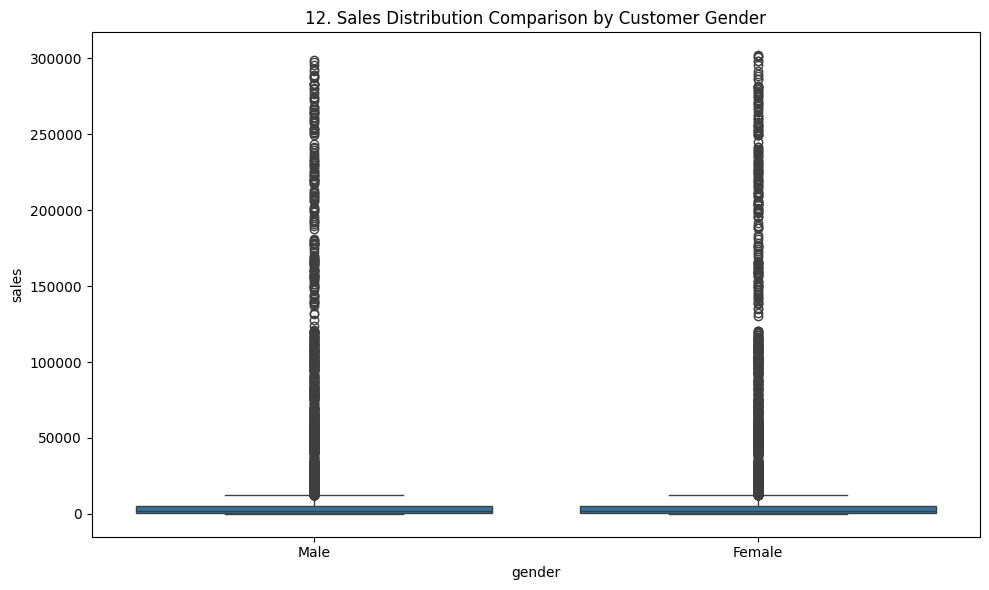

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='gender', y='sales')
plt.title(f'{plot_no}. Sales Distribution Comparison by Customer Gender')
show_fig()
plot_no += 1

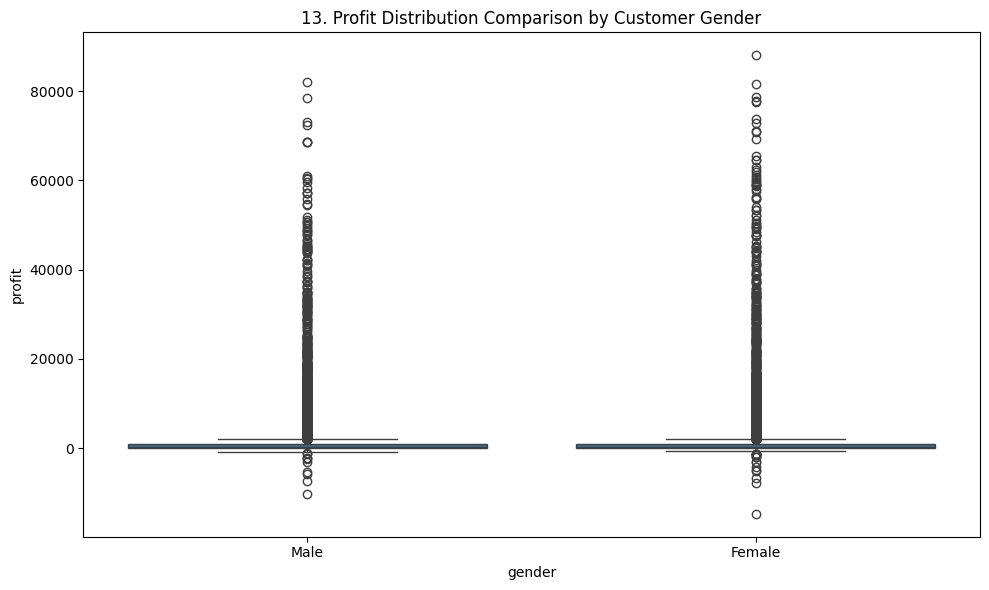

In [26]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='gender', y='profit')
plt.title(f'{plot_no}. Profit Distribution Comparison by Customer Gender')
show_fig()
plot_no += 1

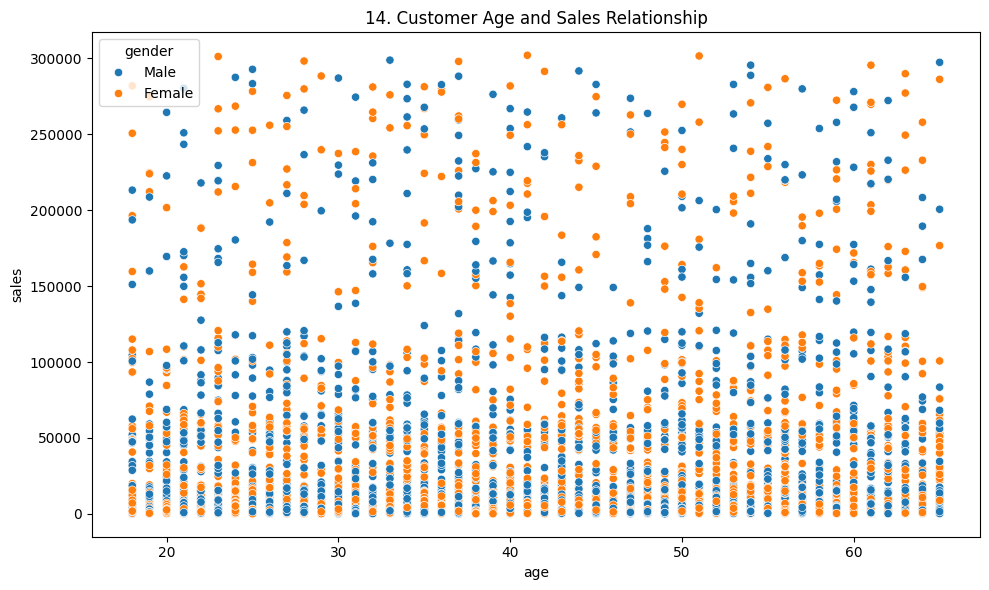

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='age', y='sales', hue='gender')
plt.title(f'{plot_no}. Customer Age and Sales Relationship')
show_fig()
plot_no += 1

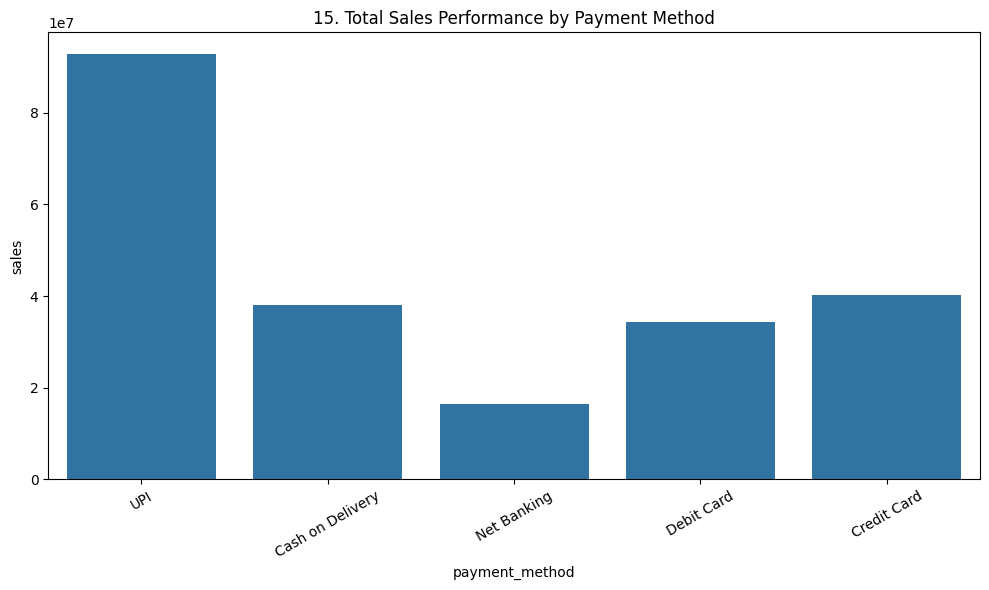

In [28]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='payment_method', y='sales', estimator='sum', errorbar=None)
plt.xticks(rotation=30)
plt.title(f'{plot_no}. Total Sales Performance by Payment Method')
show_fig()
plot_no += 1

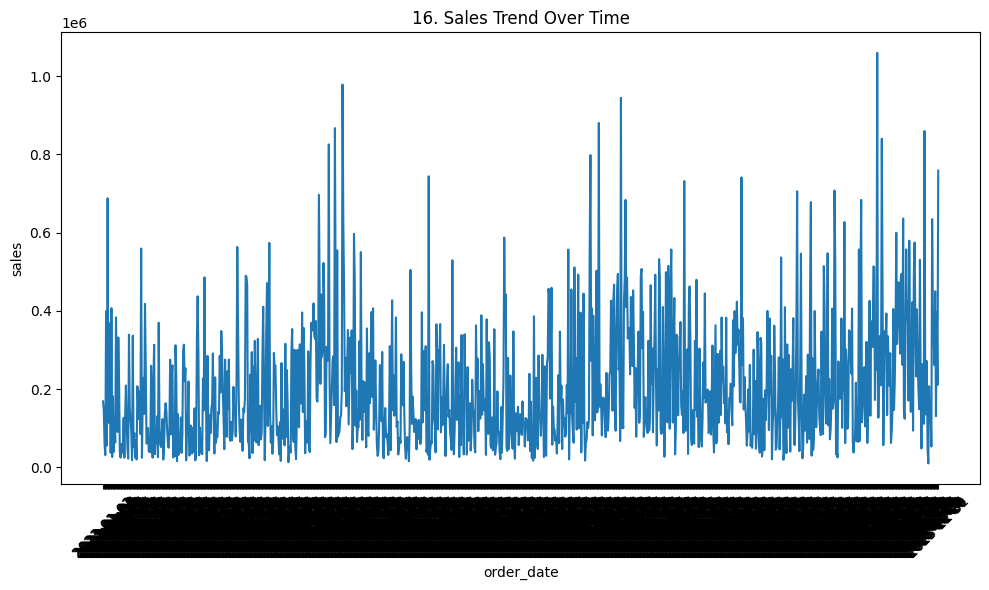

In [29]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='order_date', y='sales', estimator='sum', errorbar=None)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Sales Trend Over Time')
show_fig()
plot_no += 1

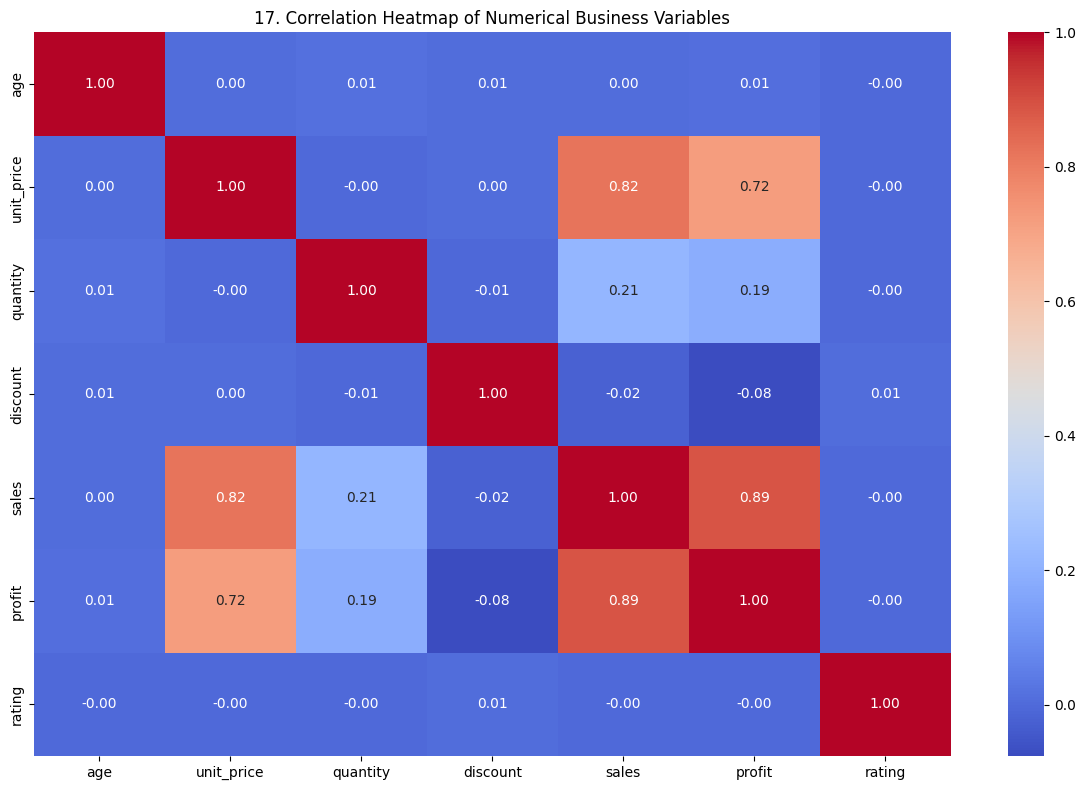

In [30]:
corr = df.select_dtypes(include='number').corr()

fig = plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Business Variables')
show_fig()
plot_no += 1

# Model Training

## Select important features and target

In [31]:
X = df[['unit_price', 'quantity', 'discount', 'sales']]
y = df['profit']

## Split data into training and testing sets

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Scale numerical features

In [33]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Create a tuned Gradient Boosting regression model

In [34]:
model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    min_samples_split=4,
    min_samples_leaf=2,
    subsample=0.9,
    loss='huber',
    random_state=42
)

## Train the model

In [35]:
model.fit(X_train, y_train)

,loss,'huber'
,learning_rate,0.03
,n_estimators,500
,subsample,0.9
,criterion,'friedman_mse'
,min_samples_split,4
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


## Generate predictions

In [36]:
y_pred = model.predict(X_test)

## Calculate model performance

In [37]:
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Accuracy Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")

R² Accuracy Score: 0.7554
RMSE: 2851.80


## Plot actual versus predicted profit

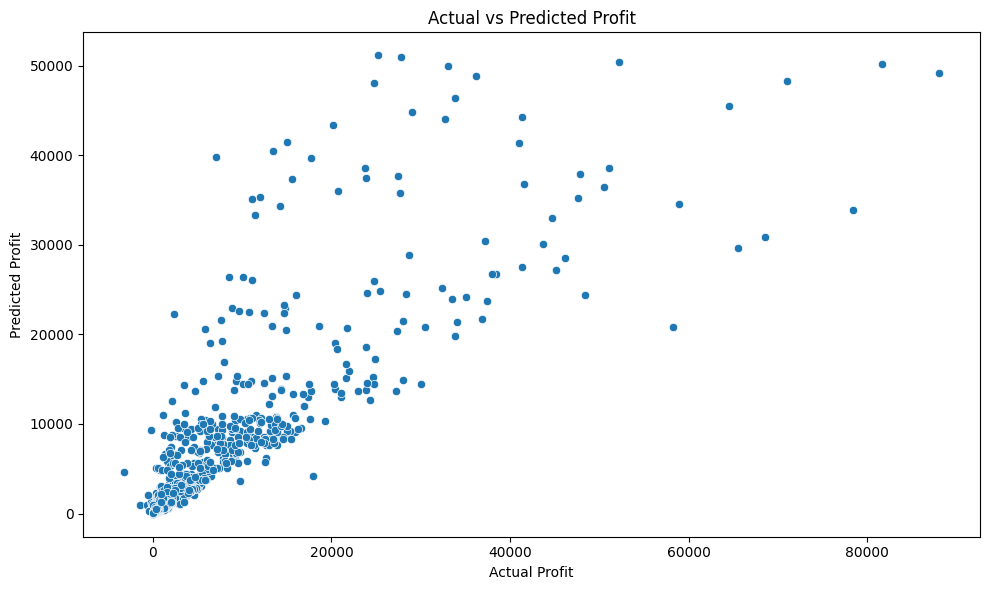

In [38]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")
show_fig()